Mapeo de categorías: {'negative': 0, 'neutral': 1, 'positive': 2}

Buscando mejores hiperparámetros...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Mejores parámetros encontrados: {'clf__C': 1, 'tfidf__max_features': 2000, 'tfidf__ngram_range': (1, 1)}
Mejor F1-Macro en CV (train): 0.7191
CV Accuracy : 0.8306 ± 0.0164
CV F1-Macro : 0.7289 ± 0.0173


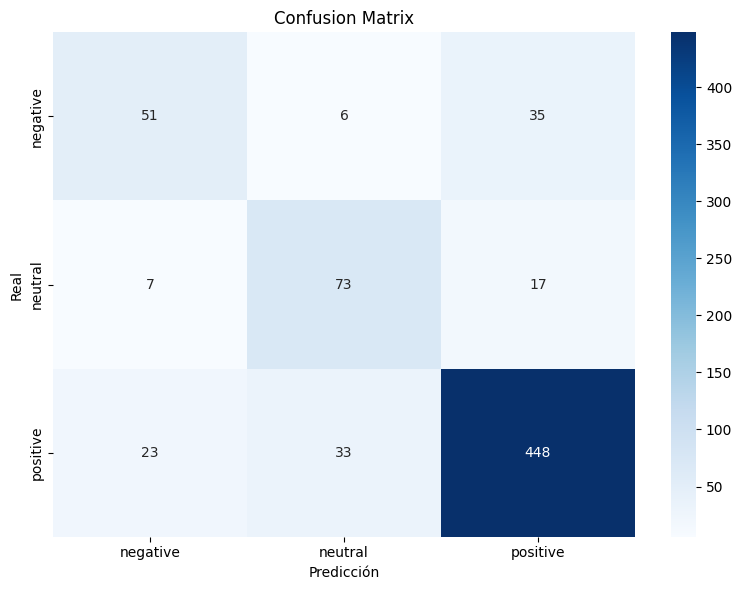

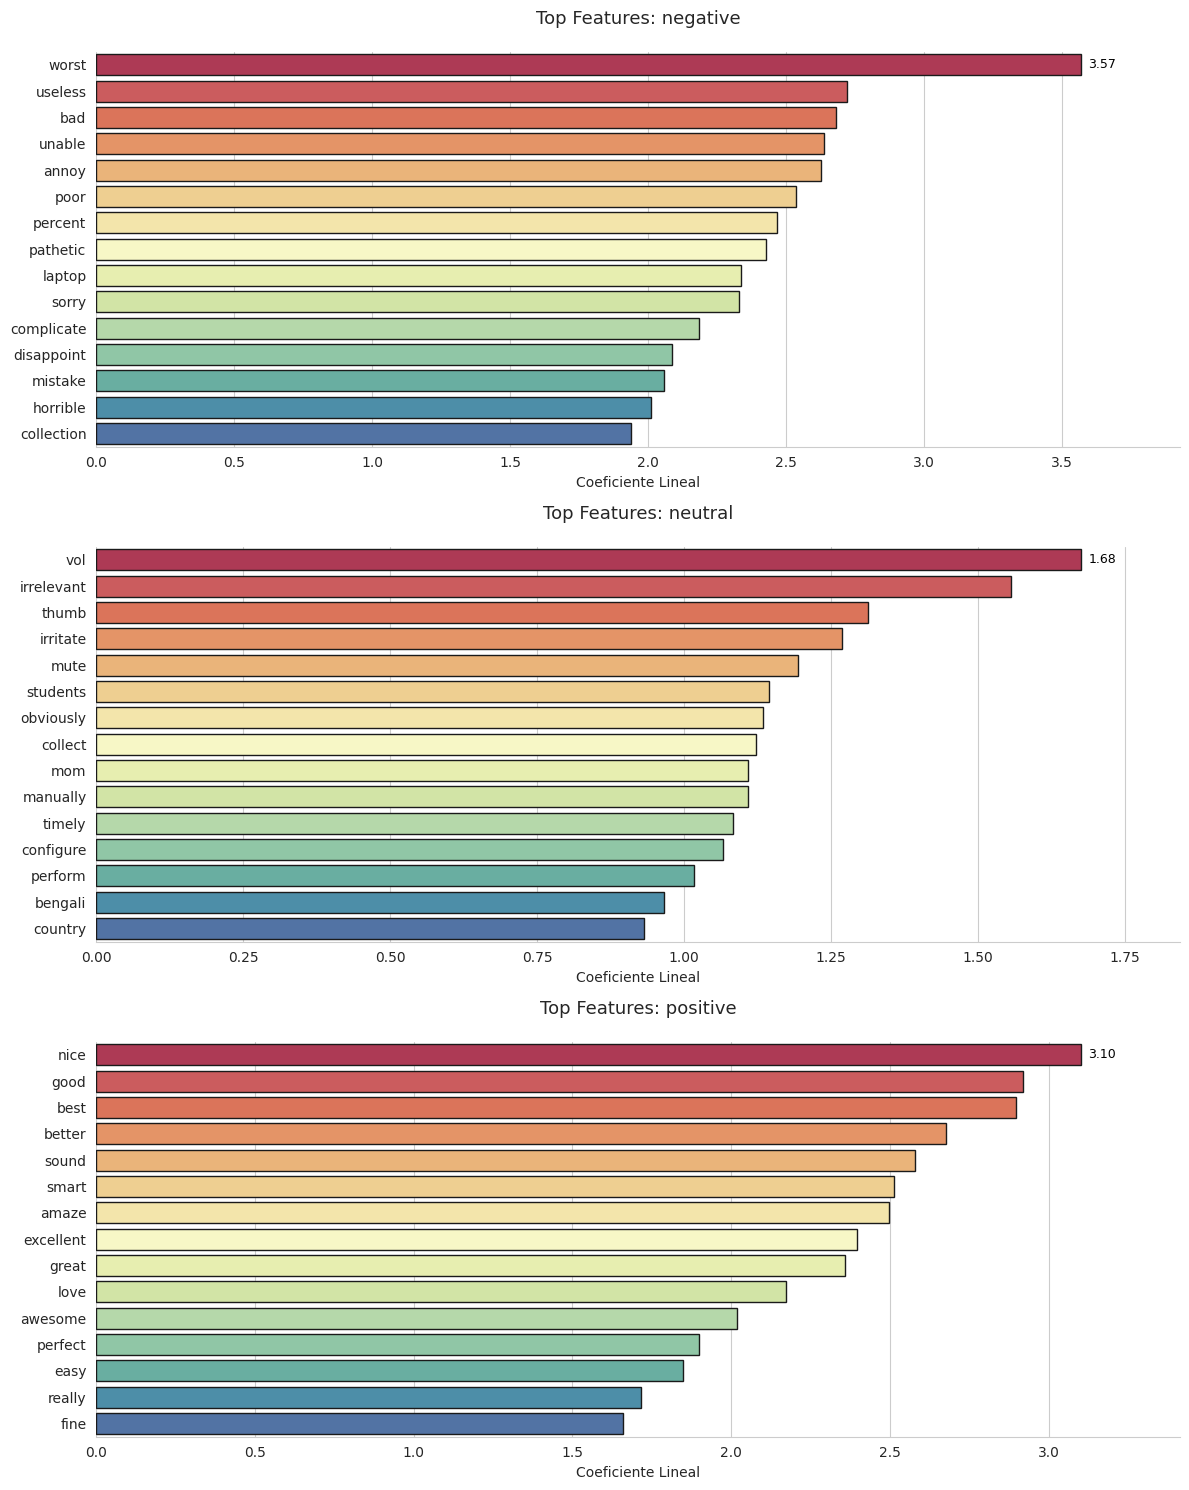

In [1]:
import os
import re
import joblib
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

random.seed(42)

df = pd.read_csv("EcoPreprocessed.csv")
df = df[["review", "division"]] # Uno dataset con solo dos columnas

# Se eliminan nulos y duplicados antes de limpiar el texto para evitar errores
df = df.dropna(subset=["review", "division"])
df = df.drop_duplicates("review")

# Prepara el texto del dataset
def clean(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text) # Elimina URLs
    text = re.sub(r"[^a-z\s]", "", text) # Elimina caracteres especiales
    text = re.sub(r"\s+", " ", text).strip() # Elimina espacios extra
    return text

# LabelEncoder convierte las categorías (positive, negative, neutral) a números
le = LabelEncoder()
df["division"] = le.fit_transform(df["division"])
label_mapping = dict(zip(le.classes_, range(len(le.classes_))))
print("Mapeo de categorías:", label_mapping)

# Separamos el dataset
X = df["review"]
y = df["division"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # Dividimos los datos 80% para entrenar y el 20% para prueba

# Creamos el modelo
modelo = Pipeline([
    ("tfidf", TfidfVectorizer(
        preprocessor=clean,
        stop_words="english",
        max_df=0.95,
        min_df=2,
        ngram_range=(1, 2),
        sublinear_tf=True,
    )),
    ("clf", LinearSVC(class_weight="balanced", max_iter=5000))
])

print("\nBuscando mejores hiperparámetros...")

# Crea varios modelos con estos paramentros y selecciona el mejor
param_grid = {
    "tfidf__max_features":[1000, 2000, 5000],
    "tfidf__ngram_range":[(1, 1), (1, 2)],
    "clf__C":[0.01, 0.1, 1, 10]
}

# GridSearchCV se encargar de crear los modelos
grid = GridSearchCV(
    modelo,
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train) # Entrena lo modelo
print("Mejores parámetros encontrados:", grid.best_params_)
print(f"Mejor F1-Macro en CV (train): {grid.best_score_:.4f}")

modelo = grid.best_estimator_ # Selecciona el mejor modelo

pred = modelo.predict(X_test)# Probamos el modelo con los datos de prueba

# Validación cruzada con 5 folds para medir estabilidad del mode
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
acc = cross_val_score(modelo, X, y, cv=cv, scoring="accuracy")
f1 = cross_val_score(modelo, X, y, cv=cv, scoring="f1_macro")

print(f"CV Accuracy : {acc.mean():.4f} ± {acc.std():.4f}")
print(f"CV F1-Macro : {f1.mean():.4f} ± {f1.std():.4f}")

# Grafica Confusion Matrix, Nos muestra claramente cuántos aciertos hubo y en qué se confundió el modelo
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title("Confusion Matrix")
plt.ylabel("Real")
plt.xlabel("Predicción")
plt.tight_layout()
plt.show()

# Gráfica que muestra qué palabras influyen más en la decisión del modelo
tfidf        = modelo.named_steps["tfidf"]
clf          = modelo.named_steps["clf"]
feature_names = tfidf.get_feature_names_out()
unique_labels = le.classes_
num_classes   = len(unique_labels)

sns.set_style("whitegrid") # Grilla suave
plt.figure(figsize=(12, 5 * num_classes))

for i, label in enumerate(unique_labels):
    top_indices = clf.coef_[i].argsort()[-15:][::-1]
    top_features = [feature_names[idx] for idx in top_indices]
    top_weights = clf.coef_[i][top_indices]

    plt.subplot(num_classes, 1, i + 1)

    ax = sns.barplot(
        x=top_weights,
        y=top_features,
        hue=top_features,
        palette="Spectral",
        edgecolor=".1",
        legend=False
    )

    ax.bar_label(
        ax.containers[0],
        fmt='%.2f',
        padding=5,
        fontsize=9,
        color='black'
    )

    plt.title(f"Top Features: {label}", fontsize=13, pad=20)
    plt.xlabel("Coeficiente Lineal")
    plt.xlim(0, max(top_weights) * 1.1)
    sns.despine(left=True, top=True)
plt.tight_layout()
plt.show()